SVM Classification for Parkinson's Dataset

Train SVM with RBF kernel on both data splits:
- Dataset A (imputed): NaNs filled with per-group median
- Dataset B (dropped): rows with NaN removed

Preprocessing: log-transform 18 skewed features and apply StandardScaler.
Nested GroupKFold CV (grouped by subject) to prevent data leakage.

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

PALETTE = {
    # binary
    "PD":       "#E24B4A",   # red-400
    "Healthy":  "#378ADD",   # blue-400
    # classifiers
    "SVM":      "#7F77DD",   # purple-400
    "HGB":      "#1D9E75",   # teal-400
    "LR":       "#BA7517",   # amber-600
    "RF":       "#B07FC8",   # soft purple
    # feature subsets
    "All":      "#D4537E",   # pink-400
    "JS":       "#639922",   # green-400  (jitter+shimmer)
}
ALPHA_WITH    = 1.00   # bars/markers with outliers
ALPHA_WITHOUT = 0.45   # bars/markers without outliers

plt.rcParams.update({
    "figure.dpi":      150,
    "font.family":     "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")


Load Data

In [16]:
train_a = pd.read_csv('../../data/train_a.csv')
test_a  = pd.read_csv('../../data/test_a.csv')
train_b = pd.read_csv('../../data/train_b.csv')
test_b  = pd.read_csv('../../data/test_b.csv')

feature_cols = [c for c in train_a.columns if c not in ('name', 'status')]
print(f'Features: {len(feature_cols)}')
print(f'Dataset A train: {len(train_a)}, test: {len(test_a)}')
print(f'Dataset B train: {len(train_b)}, test: {len(test_b)}')

Features: 22
Dataset A train: 152, test: 43
Dataset B train: 146, test: 41


Preprocessing

Log-transform the 18 skewed features identified in normality_testing.ipynb (all that failed Shapiro-Wilk with positive skew). Then apply StandardScaler.

LogTransformer stores the per-feature sign and min during fit() so no statistics from validation folds leak into training.

In [17]:
SKEWED_FEATURES = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'PPE', 'spread1', 'D2',
]


class LogTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values


pipe = Pipeline([
    ('log',    LogTransformer(skewed_cols=SKEWED_FEATURES, all_cols=feature_cols)),
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)),
])

param_grid = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto']}
print('Pipeline steps:', list(pipe.named_steps))
print('Hyperparameter grid:', param_grid)

Pipeline steps: ['log', 'scaler', 'svm']
Hyperparameter grid: {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto']}


Nested Cross-Validation loop across different folds, and different hyperparameters:

GroupKFold groups recordings by subject so the same subject never appears in both train and validation fold — prevents leakage from the ~6 recordings per subject.

- Outer loop (k = 5 and k = 7): unbiased performance estimation
- Inner loop (k = 5): GridSearchCV over C in {0.1, 1, 10, 100} × gamma in {scale, auto}, scored by macro F1

In [18]:
def nested_cv(estimator, param_grid, X, y, groups, outer_k, inner_k=5):
    outer_cv = GroupKFold(n_splits=outer_k)
    inner_cv = GroupKFold(n_splits=inner_k)
    fold_acc, fold_ba, fold_f1, best_params_list = [], [], [], []

    for train_idx, val_idx in outer_cv.split(X, y, groups):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        g_tr        = groups[train_idx]

        gs = GridSearchCV(
            estimator, param_grid,
            cv=inner_cv, scoring='f1_macro', refit=True, n_jobs=1,
        )
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_val)
        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_ba.append(balanced_accuracy_score(y_val, y_pred))
        fold_f1.append(f1_score(y_val, y_pred, average='macro'))
        best_params_list.append(gs.best_params_)

    return {
        'accuracy':          np.array(fold_acc),
        'balanced_accuracy': np.array(fold_ba),
        'f1_macro':          np.array(fold_f1),
        'best_params':       best_params_list,
    }

In [19]:
datasets = {
    'A (imputed)': train_a,
    'B (dropped)': train_b,
}
k_values = [5, 7]

results = {}
for ds_name, train_df in datasets.items():
    X      = train_df[feature_cols].values
    y      = train_df['status'].values
    groups = train_df['name'].str.rsplit('_', n=1).str[0].values

    for k in k_values:
        print(f'Dataset {ds_name}, k={k} ...', flush=True)
        res = nested_cv(pipe, param_grid, X, y, groups, outer_k=k)
        results[(ds_name, k)] = res
        am  = res['accuracy'].mean()
        as_ = res['accuracy'].std()
        bm  = res['balanced_accuracy'].mean()
        bs  = res['balanced_accuracy'].std()
        fm  = res['f1_macro'].mean()
        fs  = res['f1_macro'].std()
        bp  = res['best_params']
        print(f'  accuracy          : {am:.3f} ± {as_:.3f}')
        print(f'  balanced accuracy : {bm:.3f} ± {bs:.3f}')
        print(f'  macro F1          : {fm:.3f} ± {fs:.3f}')
        print(f'  best params: {bp}')
        print()

Dataset A (imputed), k=5 ...
  accuracy          : 0.683 ± 0.126
  balanced accuracy : 0.632 ± 0.163
  macro F1          : 0.512 ± 0.119
  best params: [{'svm__C': 10, 'svm__gamma': 'scale'}, {'svm__C': 0.1, 'svm__gamma': 'scale'}, {'svm__C': 0.1, 'svm__gamma': 'scale'}, {'svm__C': 100, 'svm__gamma': 'scale'}, {'svm__C': 1, 'svm__gamma': 'scale'}]

Dataset A (imputed), k=7 ...
  accuracy          : 0.709 ± 0.138
  balanced accuracy : 0.693 ± 0.142
  macro F1          : 0.507 ± 0.112
  best params: [{'svm__C': 100, 'svm__gamma': 'scale'}, {'svm__C': 100, 'svm__gamma': 'scale'}, {'svm__C': 0.1, 'svm__gamma': 'scale'}, {'svm__C': 0.1, 'svm__gamma': 'scale'}, {'svm__C': 10, 'svm__gamma': 'scale'}, {'svm__C': 10, 'svm__gamma': 'scale'}, {'svm__C': 10, 'svm__gamma': 'scale'}]

Dataset B (dropped), k=5 ...
  accuracy          : 0.666 ± 0.095
  balanced accuracy : 0.551 ± 0.132
  macro F1          : 0.493 ± 0.131
  best params: [{'svm__C': 10, 'svm__gamma': 'scale'}, {'svm__C': 1, 'svm__gamma'

Results

In [20]:
rows = []
for (ds_name, k), res in results.items():
    rows.append({
        'Dataset':  ds_name,
        'k':        k,
        'Acc mean': round(res['accuracy'].mean(), 3),
        'Acc ±std': round(res['accuracy'].std(),  3),
        'BA mean':  round(res['balanced_accuracy'].mean(), 3),
        'BA ±std':  round(res['balanced_accuracy'].std(),  3),
        'F1 mean':  round(res['f1_macro'].mean(), 3),
        'F1 ±std':  round(res['f1_macro'].std(),  3),
    })

display(pd.DataFrame(rows))

,Dataset,k,Acc mean,Acc ±std,BA mean,BA ±std,F1 mean,F1 ±std
0,A (imputed),5,0.683,0.126,0.632,0.163,0.512,0.119
1,A (imputed),7,0.709,0.138,0.693,0.142,0.507,0.112
2,B (dropped),5,0.666,0.095,0.551,0.132,0.493,0.131
3,B (dropped),7,0.749,0.106,0.725,0.126,0.538,0.150


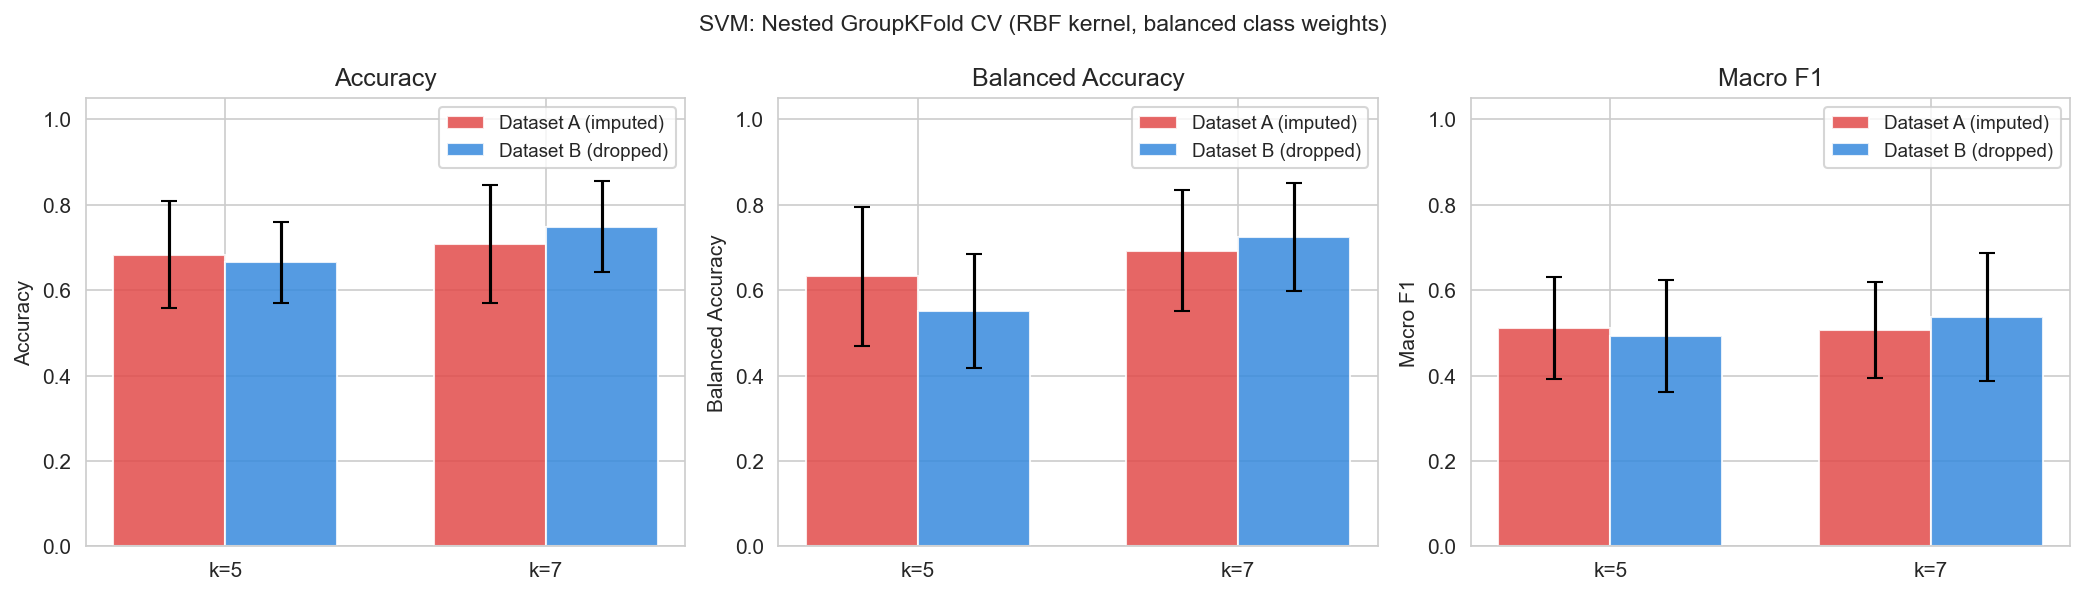

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = [('accuracy', 'Accuracy'), ('balanced_accuracy', 'Balanced Accuracy'), ('f1_macro', 'Macro F1')]
ds_labels = list(datasets)
ds_colors = {'A (imputed)': PALETTE["PD"], 'B (dropped)': PALETTE["Healthy"]}
x         = np.arange(len(k_values))
width     = 0.35

for ax, (metric, label) in zip(axes, metrics):
    for i, ds_name in enumerate(ds_labels):
        means  = [results[(ds_name, kk)][metric].mean() for kk in k_values]
        stds   = [results[(ds_name, kk)][metric].std()  for kk in k_values]
        offset = (i - 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=4,
               color=ds_colors[ds_name], alpha=0.85, label=f'Dataset {ds_name}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'k={kk}' for kk in k_values])
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

fig.suptitle('SVM: Nested GroupKFold CV (RBF kernel, balanced class weights)', fontsize=11)
plt.tight_layout()
plt.savefig('svm_cv_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Final Evaluation on Held-Out Test Sets

For each dataset, a new GridSearchCV is fitted on the full training set (inner 5-fold GroupKFold), then the best pipeline is evaluated on the held-out test set, never seen during any CV step.


Dataset A (imputed)
  Best params : {'svm__C': 100, 'svm__gamma': 'scale'}
  Accuracy    : 0.837
  Macro F1    : 0.743
  Balanced Acc: 0.708
              precision    recall  f1-score   support

     Healthy       1.00      0.42      0.59        12
          PD       0.82      1.00      0.90        31

    accuracy                           0.84        43
   macro avg       0.91      0.71      0.74        43
weighted avg       0.87      0.84      0.81        43


Dataset B (dropped)
  Best params : {'svm__C': 100, 'svm__gamma': 'scale'}
  Accuracy    : 0.829
  Macro F1    : 0.740
  Balanced Acc: 0.708
              precision    recall  f1-score   support

     Healthy       1.00      0.42      0.59        12
          PD       0.81      1.00      0.89        29

    accuracy                           0.83        41
   macro avg       0.90      0.71      0.74        41
weighted avg       0.86      0.83      0.80        41



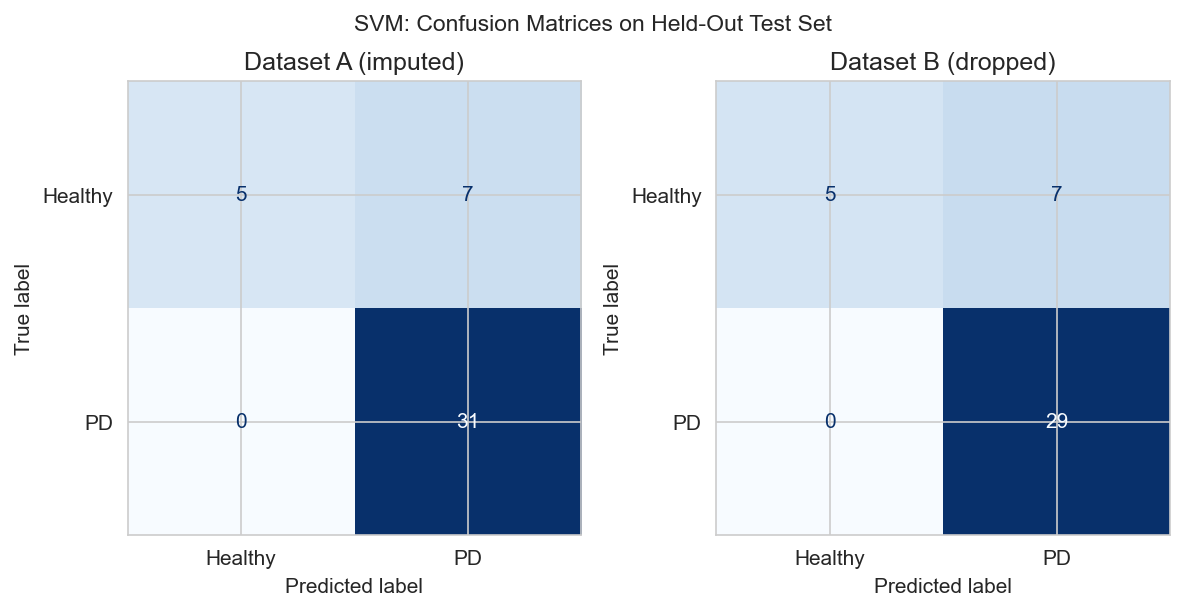

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

eval_configs = [
    ('A (imputed)', train_a, test_a),
    ('B (dropped)', train_b, test_b),
]

for ax, (ds_name, train_df, test_df) in zip(axes, eval_configs):
    X_train = train_df[feature_cols].values
    y_train = train_df['status'].values
    g_train = train_df['name'].str.rsplit('_', n=1).str[0].values
    X_test  = test_df[feature_cols].values
    y_test  = test_df['status'].values

    gs_final = GridSearchCV(
        pipe, param_grid,
        cv=GroupKFold(n_splits=5), scoring='f1_macro', refit=True, n_jobs=1,
    )
    gs_final.fit(X_train, y_train, groups=g_train)
    y_pred = gs_final.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    ba  = balanced_accuracy_score(y_test, y_pred)
    bp  = gs_final.best_params_
    print()
    print(f'Dataset {ds_name}')
    print(f'  Best params : {bp}')
    print(f'  Accuracy    : {acc:.3f}')
    print(f'  Macro F1    : {f1:.3f}')
    print(f'  Balanced Acc: {ba:.3f}')
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'PD']))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Healthy', 'PD'],
        colorbar=False, ax=ax, cmap='Blues',
    )
    ax.set_title(f'Dataset {ds_name}')

fig.suptitle('SVM: Confusion Matrices on Held-Out Test Set', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/svm_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


Feature Subset and Outlier Condition: 2x2 Comparison

Re-run the nested GroupKFold CV (k=5) across four configurations

Outliers are defined by the union of three flags from `outlier_analysis.ipynb`:
- IQR rule flagged in ≥ 3 features
- Z-score |z| > 3 in any feature  
- PCA Mahalanobis distance > 97.5th percentile

In [23]:
from sklearn.decomposition import PCA

def _fit_outlier_detector(train_df, feat_cols):
    """Fit IQR bounds, scaler, PCA(2), and Mahalanobis threshold on train_df."""
    iqr_bounds = {}
    for c in feat_cols:
        Q1, Q3 = train_df[c].quantile(0.25), train_df[c].quantile(0.75)
        iqr_bounds[c] = (Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1))

    scaler   = StandardScaler().fit(train_df[feat_cols])
    X_sc_tr  = scaler.transform(train_df[feat_cols])
    pca      = PCA(n_components=2).fit(X_sc_tr)
    X_pca_tr = pca.transform(X_sc_tr)

    mu      = X_pca_tr.mean(axis=0)
    cov_inv = np.linalg.pinv(np.cov(X_pca_tr.T))
    d       = X_pca_tr - mu
    thresh  = np.percentile(np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d)), 97.5)
    return iqr_bounds, scaler, pca, mu, cov_inv, thresh


def _apply_outlier_flags(df, feat_cols, iqr_bounds, scaler, pca, mu, cov_inv, thresh):
    """Apply fitted detector to df; returns set of outlier recording names."""
    iqr_count = np.zeros(len(df), dtype=int)
    for c, (lo, hi) in iqr_bounds.items():
        iqr_count += ((df[c].values < lo) | (df[c].values > hi)).astype(int)

    X_sc  = scaler.transform(df[feat_cols])
    X_pca = pca.transform(X_sc)
    d     = X_pca - mu
    mahal = np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d))
    mask  = (iqr_count >= 3) | (np.abs(X_sc) > 3).any(axis=1) | (mahal > thresh)
    return set(df['name'].values[mask])


# Dataset A: fit on train_a, apply to train_a and test_a
_det_a = _fit_outlier_detector(train_a, feature_cols)
train_a_outlier_names = _apply_outlier_flags(train_a, feature_cols, *_det_a)
test_a_outlier_names  = _apply_outlier_flags(test_a,  feature_cols, *_det_a)

# Dataset B: fit on train_b, apply to train_b and test_b
_det_b = _fit_outlier_detector(train_b, feature_cols)
train_b_outlier_names = _apply_outlier_flags(train_b, feature_cols, *_det_b)
test_b_outlier_names  = _apply_outlier_flags(test_b,  feature_cols, *_det_b)

print(f'Outliers A — train: {len(train_a_outlier_names)}, test: {len(test_a_outlier_names)}')
print(f'Outliers B — train: {len(train_b_outlier_names)}, test: {len(test_b_outlier_names)}')

# Filter train/test splits
train_a_clean = train_a[~train_a['name'].isin(train_a_outlier_names)].reset_index(drop=True)
test_a_clean  = test_a[~test_a['name'].isin(test_a_outlier_names)].reset_index(drop=True)
train_b_clean = train_b[~train_b['name'].isin(train_b_outlier_names)].reset_index(drop=True)
test_b_clean  = test_b[~test_b['name'].isin(test_b_outlier_names)].reset_index(drop=True)

print(f'Train A: {len(train_a)} → {len(train_a_clean)} | Test A: {len(test_a)} → {len(test_a_clean)}')
print(f'Train B: {len(train_b)} → {len(train_b_clean)} | Test B: {len(test_b)} → {len(test_b_clean)}')


Outliers A — train: 22, test: 7
Outliers B — train: 21, test: 7
Train A: 152 → 130 | Test A: 43 → 36
Train B: 146 → 125 | Test B: 41 → 34


In [24]:
import warnings
warnings.filterwarnings('ignore')

JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA',
]

feature_sets = {
    'All features':   feature_cols,
    'Jitter+Shimmer': JITTER_SHIMMER,
}

outlier_configs = {
    'With outliers':    {'A': (train_a,       test_a),       'B': (train_b,       test_b)},
    'Without outliers': {'A': (train_a_clean, test_a_clean), 'B': (train_b_clean, test_b_clean)},
}

results_2x2 = {}
configs_2x2 = {}

for feat_label, cols in feature_sets.items():
    skewed_sub = [c for c in SKEWED_FEATURES if c in cols]
    for outlier_label, splits in outlier_configs.items():
        for ds_label, (tr, te) in [('A (imputed)', splits['A']), ('B (dropped)', splits['B'])]:
            key = (feat_label, outlier_label, ds_label)
            print(f'{feat_label} | {outlier_label} | Dataset {ds_label} ...', flush=True)

            pipe_run = Pipeline([
                ('log',    LogTransformer(skewed_cols=skewed_sub, all_cols=cols)),
                ('scaler', StandardScaler()),
                ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=42)),
            ])

            X      = tr[cols].values
            y      = tr['status'].values
            groups = tr['name'].str.rsplit('_', n=1).str[0].values

            res = nested_cv(pipe_run, param_grid, X, y, groups, outer_k=5)
            results_2x2[key] = res
            configs_2x2[key] = {'train_df': tr, 'test_df': te, 'cols': cols, 'skewed': skewed_sub}

            print(f'  balanced acc : {res["balanced_accuracy"].mean():.3f} ± {res["balanced_accuracy"].std():.3f}')
            print(f'  macro F1     : {res["f1_macro"].mean():.3f} ± {res["f1_macro"].std():.3f}')
            print()

All features | With outliers | Dataset A (imputed) ...
  balanced acc : 0.632 ± 0.163
  macro F1     : 0.512 ± 0.119

All features | With outliers | Dataset B (dropped) ...
  balanced acc : 0.551 ± 0.132
  macro F1     : 0.493 ± 0.131

All features | Without outliers | Dataset A (imputed) ...
  balanced acc : 0.543 ± 0.251
  macro F1     : 0.337 ± 0.129

All features | Without outliers | Dataset B (dropped) ...
  balanced acc : 0.597 ± 0.165
  macro F1     : 0.518 ± 0.151

Jitter+Shimmer | With outliers | Dataset A (imputed) ...
  balanced acc : 0.583 ± 0.141
  macro F1     : 0.482 ± 0.104

Jitter+Shimmer | With outliers | Dataset B (dropped) ...
  balanced acc : 0.539 ± 0.123
  macro F1     : 0.515 ± 0.160

Jitter+Shimmer | Without outliers | Dataset A (imputed) ...
  balanced acc : 0.554 ± 0.209
  macro F1     : 0.379 ± 0.120

Jitter+Shimmer | Without outliers | Dataset B (dropped) ...
  balanced acc : 0.545 ± 0.153
  macro F1     : 0.489 ± 0.134



In [25]:
rows = []
for (feat_label, outlier_label, ds_label), res in results_2x2.items():
    rows.append({
        'Feature set':   feat_label,
        'Outliers':      outlier_label,
        'Dataset':       ds_label,
        'Accuracy':      f'{res["accuracy"].mean():.3f} ± {res["accuracy"].std():.3f}',
        'Balanced Acc':  f'{res["balanced_accuracy"].mean():.3f} ± {res["balanced_accuracy"].std():.3f}',
        'Macro F1':      f'{res["f1_macro"].mean():.3f} ± {res["f1_macro"].std():.3f}',
    })
display(pd.DataFrame(rows))

,Feature set,Outliers,Dataset,Accuracy,Balanced Acc,Macro F1
0,All features,With outliers,A (imputed),0.683 ± 0.126,0.632 ± 0.163,0.512 ± 0.119
1,All features,With outliers,B (dropped),0.666 ± 0.095,0.551 ± 0.132,0.493 ± 0.131
2,All features,Without outliers,A (imputed),0.561 ± 0.275,0.543 ± 0.251,0.337 ± 0.129
3,All features,Without outliers,B (dropped),0.636 ± 0.119,0.597 ± 0.165,0.518 ± 0.151
4,Jitter+Shimmer,With outliers,A (imputed),0.611 ± 0.133,0.583 ± 0.141,0.482 ± 0.104
5,Jitter+Shimmer,With outliers,B (dropped),0.650 ± 0.123,0.539 ± 0.123,0.515 ± 0.160
6,Jitter+Shimmer,Without outliers,A (imputed),0.532 ± 0.227,0.554 ± 0.209,0.379 ± 0.120
7,Jitter+Shimmer,Without outliers,B (dropped),0.585 ± 0.137,0.545 ± 0.153,0.489 ± 0.134


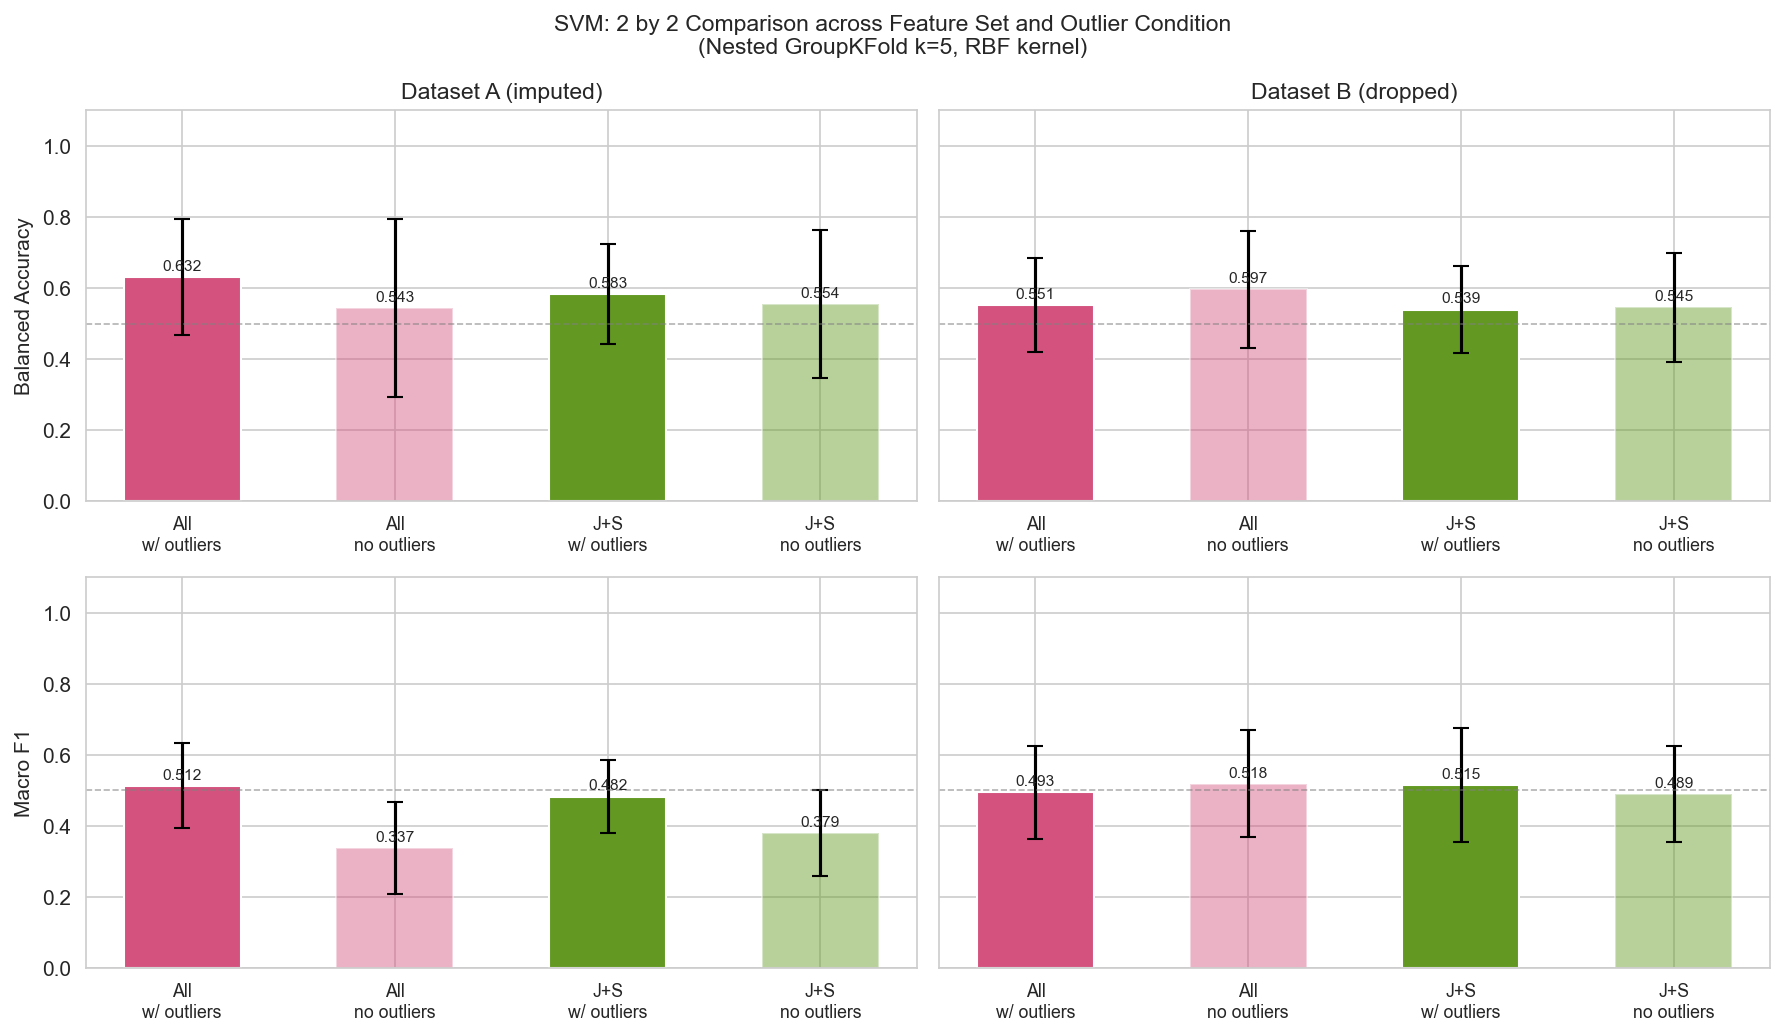

In [26]:
metrics     = [('balanced_accuracy', 'Balanced Accuracy'), ('f1_macro', 'Macro F1')]
ds_labels   = ['A (imputed)', 'B (dropped)']
# 4 bars per subplot: All+outliers, All-outliers, J+S+outliers, J+S-outliers
bar_keys    = [
    ('All features',   'With outliers'),
    ('All features',   'Without outliers'),
    ('Jitter+Shimmer', 'With outliers'),
    ('Jitter+Shimmer', 'Without outliers'),
]
bar_labels  = ['All\nw/ outliers', 'All\nno outliers', 'J+S\nw/ outliers', 'J+S\nno outliers']
bar_colors  = [PALETTE["All"], PALETTE["All"], PALETTE["JS"], PALETTE["JS"]]
bar_alphas  = [ALPHA_WITH, ALPHA_WITHOUT, ALPHA_WITH, ALPHA_WITHOUT]
x           = np.arange(len(bar_keys))
width       = 0.55

fig, axes = plt.subplots(len(metrics), len(ds_labels), figsize=(12, 7), sharey='row')

for row_i, (metric, metric_label) in enumerate(metrics):
    for col_i, ds_label in enumerate(ds_labels):
        ax = axes[row_i, col_i]
        means = [results_2x2[(fl, ol, ds_label)][metric].mean() for fl, ol in bar_keys]
        stds  = [results_2x2[(fl, ol, ds_label)][metric].std()  for fl, ol in bar_keys]

        bars = [ax.bar(x[bi], means[bi], width, yerr=stds[bi], capsize=4,
                       color=bar_colors[bi], alpha=bar_alphas[bi], edgecolor='white')[0]
                for bi in range(len(x))]
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7.5)

        ax.set_xticks(x)
        ax.set_xticklabels(bar_labels, fontsize=8.5)
        ax.set_ylim(0, 1.1)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_ylabel(metric_label if col_i == 0 else '')
        if row_i == 0:
            ax.set_title(f'Dataset {ds_label}', fontsize=11)

fig.suptitle('SVM: 2 by 2 Comparison across Feature Set and Outlier Condition\n(Nested GroupKFold k=5, RBF kernel)', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/svm_2x2_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Final Evaluation on Held-Out Test Sets (2×2 Grid)

For each of the 8 configurations, fit GridSearchCV on the full training set and evaluate on the held-out test set.

In [27]:
test_rows = []

for (feat_label, outlier_label, ds_label), cfg in configs_2x2.items():
    tr, te   = cfg['train_df'], cfg['test_df']
    cols     = cfg['cols']
    skewed_s = cfg['skewed']

    pipe_final = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed_s, all_cols=cols)),
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=42)),
    ])

    X_train = tr[cols].values
    y_train = tr['status'].values
    g_train = tr['name'].str.rsplit('_', n=1).str[0].values
    X_test  = te[cols].values
    y_test  = te['status'].values

    gs = GridSearchCV(pipe_final, param_grid,
                      cv=GroupKFold(n_splits=5), scoring='f1_macro',
                      refit=True, n_jobs=1)
    gs.fit(X_train, y_train, groups=g_train)
    y_pred = gs.predict(X_test)

    test_rows.append({
        'Feature set':  feat_label,
        'Outliers':     outlier_label,
        'Dataset':      ds_label,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'Balanced Acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'Macro F1':     round(f1_score(y_test, y_pred, average='macro'), 3),
        'Best C':       gs.best_params_['svm__C'],
        'Best gamma':   gs.best_params_['svm__gamma'],
    })

display(pd.DataFrame(test_rows))


,Feature set,Outliers,Dataset,Accuracy,Balanced Acc,Macro F1,Best C,Best gamma
0,All features,With outliers,A (imputed),0.837,0.708,0.743,100.0,scale
1,All features,With outliers,B (dropped),0.829,0.708,0.740,100.0,scale
2,All features,Without outliers,A (imputed),0.917,0.850,0.884,0.1,scale
3,All features,Without outliers,B (dropped),0.853,0.750,0.786,10.0,scale
4,Jitter+Shimmer,With outliers,A (imputed),0.860,0.750,0.789,100.0,scale
5,Jitter+Shimmer,With outliers,B (dropped),0.878,0.792,0.829,100.0,scale
6,Jitter+Shimmer,Without outliers,A (imputed),0.861,0.750,0.789,100.0,scale
7,Jitter+Shimmer,Without outliers,B (dropped),0.882,0.800,0.837,100.0,scale


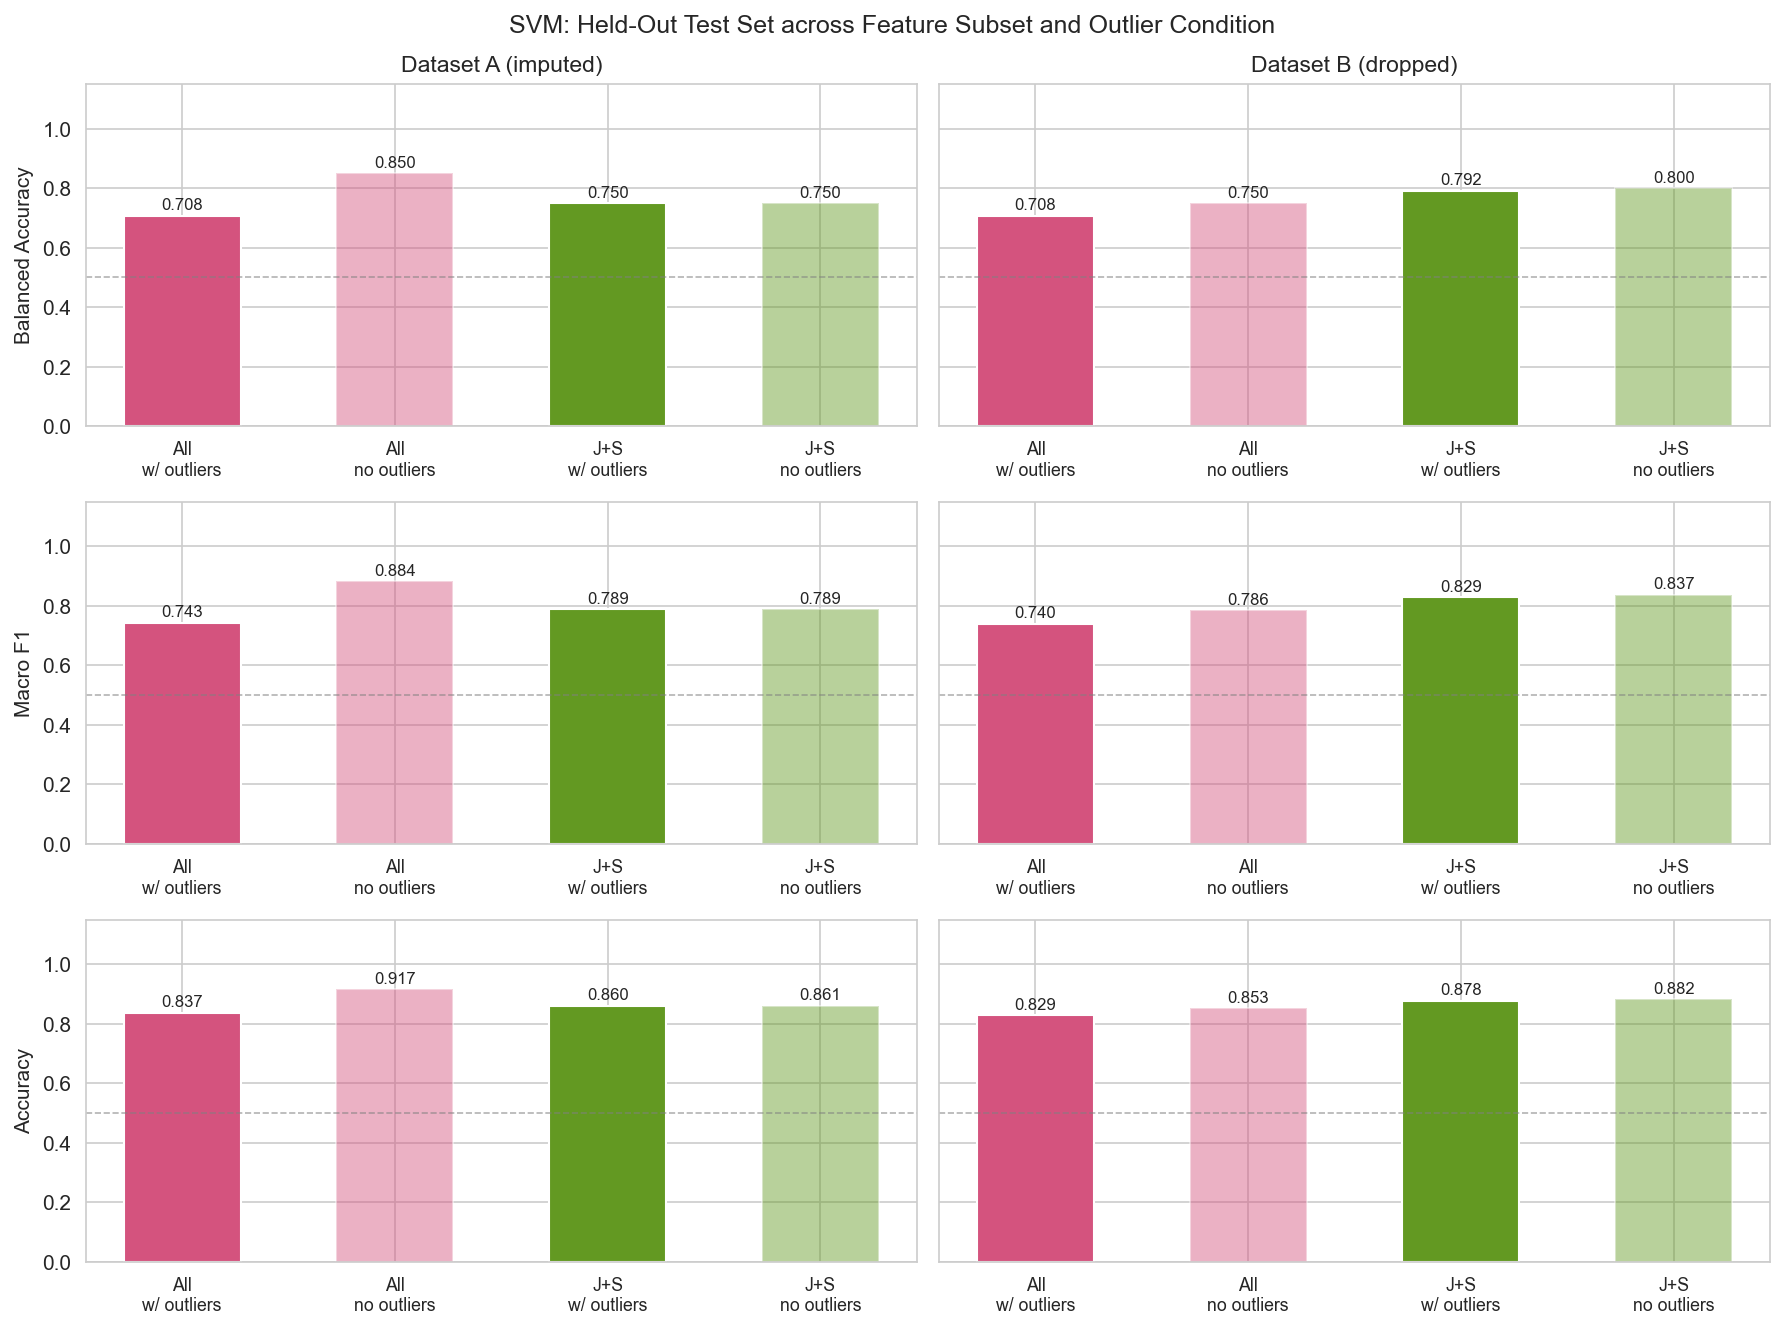

In [28]:
test_df_plot = pd.DataFrame(test_rows)

metrics_test = [('Balanced Acc', 'Balanced Accuracy'), ('Macro F1', 'Macro F1'), ('Accuracy', 'Accuracy')]
ds_labels_t  = ['A (imputed)', 'B (dropped)']
bar_keys_t   = [
    ('All features',   'With outliers'),
    ('All features',   'Without outliers'),
    ('Jitter+Shimmer', 'With outliers'),
    ('Jitter+Shimmer', 'Without outliers'),
]
bar_labels_t = ['All\nw/ outliers', 'All\nno outliers', 'J+S\nw/ outliers', 'J+S\nno outliers']
bar_colors_t = [PALETTE["All"], PALETTE["All"], PALETTE["JS"], PALETTE["JS"]]
bar_alphas_t = [ALPHA_WITH, ALPHA_WITHOUT, ALPHA_WITH, ALPHA_WITHOUT]
x_t          = np.arange(len(bar_keys_t))
width_t      = 0.55

fig, axes = plt.subplots(len(metrics_test), len(ds_labels_t), figsize=(12, 9), sharey='row')

for row_i, (metric_col, metric_label) in enumerate(metrics_test):
    for col_i, ds_label in enumerate(ds_labels_t):
        ax = axes[row_i, col_i]
        vals = [
            test_df_plot.loc[
                (test_df_plot['Feature set'] == fl) &
                (test_df_plot['Outliers']     == ol) &
                (test_df_plot['Dataset']      == ds_label),
                metric_col
            ].values[0]
            for fl, ol in bar_keys_t
        ]

        bars = [ax.bar(x_t[bi], vals[bi], width_t,
                       color=bar_colors_t[bi], alpha=bar_alphas_t[bi], edgecolor='white')[0]
                for bi in range(len(x_t))]
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x_t)
        ax.set_xticklabels(bar_labels_t, fontsize=8.5)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_ylabel(metric_label if col_i == 0 else '')
        if row_i == 0:
            ax.set_title(f'Dataset {ds_label}', fontsize=11)

fig.suptitle('SVM: Held-Out Test Set across Feature Subset and Outlier Condition', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/svm_2x2_test_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()